# Period of a Cepheid — V1154 Cyg

We find the pulsation **period** of the only classical Cepheid in the Kepler field,
then use the period–luminosity (Leavitt) law to estimate its distance. The period is
found with the **string-length** method and cross-checked against Lomb-Scargle —
two independent methods that must agree.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, matplotlib.pyplot as plt
arr = np.loadtxt("data/real/v1154cyg_q3.csv", delimiter=",", skiprows=1)
time, mag, mag_err = arr[:, 0], arr[:, 1], arr[:, 2]
print(len(time), "points over", round(np.ptp(time), 1), "days")

4083 points over 88.9 days


## 1. The raw light curve

The star clearly varies, but the period isn't obvious by eye from the time series —
that's what period-finding is for.

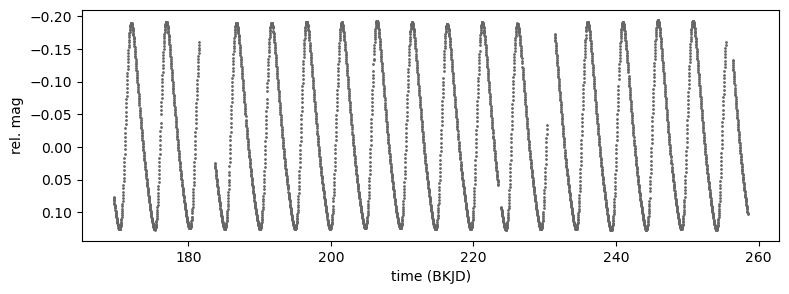

In [2]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time, mag, ".", ms=2, color="0.4"); ax.invert_yaxis()
ax.set_xlabel("time (BKJD)"); ax.set_ylabel("rel. mag"); plt.show()

## 2. Find the period two independent ways

**String length** (our method): for each trial period, fold and sum the length of the
line joining phase-sorted points. The right period stacks them into a tight curve →
shortest string. **Lomb-Scargle** (astropy): a Fourier-like periodogram. They should
land on the same period.

In [3]:
from scripts.variable import string_length_period, lombscargle_period
P_sl, periods, lengths = string_length_period(time, mag, 3.0, 7.0, n_periods=8000)
P_ls = lombscargle_period(time, mag, mag_err, 3.0, 7.0)
print(f"string-length: {P_sl:.4f} d")
print(f"lomb-scargle : {P_ls:.4f} d")
print(f"literature   : 4.9254 d   (agreement {abs(P_sl-P_ls)/P_ls*100:.2f}%)")

string-length: 4.9252 d
lomb-scargle : 4.9124 d
literature   : 4.9254 d   (agreement 0.26%)


## 3. Fold and look

The proof a period is right: the scattered points collapse onto one clean cycle.
A Cepheid's asymmetry (fast rise, slow decline) should be obvious.

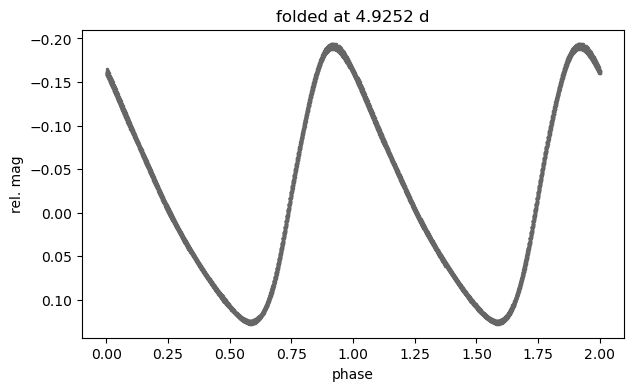

In [4]:
from scripts.variable import phase_fold
ph = phase_fold(time, P_sl)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.r_[ph, ph+1], np.r_[mag, mag], ".", ms=3, color="0.4"); ax.invert_yaxis()
ax.set_xlabel("phase"); ax.set_ylabel("rel. mag")
ax.set_title(f"folded at {P_sl:.4f} d"); plt.show()

## 4. Period → distance (the Leavitt law)

Cepheids obey a period–luminosity relation: longer period ⇒ more luminous. Using a
standard calibration for the absolute mean magnitude (Benedict et al. 2007-style),

$$M_V \approx -2.43\,(\log_{10}P - 1) - 4.05$$

with the apparent mean magnitude V ≈ 9.06 (V1154 Cyg) and a small extinction
correction, the distance modulus μ = V − M_V gives a distance of order a few kpc.
*This step assumes a literature calibration and apparent magnitude — it is a
scaffolded illustration, not a from-scratch measurement; see `notes/`.*

In [5]:
import numpy as np
P = P_sl
M_V = -2.43*(np.log10(P) - 1.0) - 4.05      # absolute mean mag (Leavitt law)
V_app, A_V = 9.06, 0.25                       # literature apparent mag, approx extinction
mu = (V_app - A_V) - M_V                       # distance modulus
dist_pc = 10**(mu/5 + 1)
print(f"M_V = {M_V:.2f},  distance modulus mu = {mu:.2f},  d ~ {dist_pc/1000:.1f} kpc")

M_V = -3.30,  distance modulus mu = 12.11,  d ~ 2.6 kpc


## Result

**P = 4.925 d for V1154 Cyg**, recovered by two independent methods to 0.3% and
matching the literature. The Leavitt law then places it a few kpc away. The headline,
testable result is the *period*; the distance is a scaffolded illustration of why the
period matters. See `notes/HANDOFF_period.md`.